<a href="https://colab.research.google.com/github/BambinoBerserkEva01/Simulacion_Estocastica/blob/main/Practica_Primer_Parcial_Regresion_CON_REPORTE_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Práctica: Regresión Lineal Simple Extendida
**Autor:** Héctor Madera

Este notebook resuelve paso a paso:
- Estimación de b₀ y b₁
- Cálculo de SSres y MSres
- Pruebas de hipótesis para b₀ y b₁
- Intervalos de confianza y predicción
- Análisis del modelo (significancia global)
- Evaluación de la dependencia de los estimadores
- Distribución de estimaciones usando 10 réplicas


In [ ]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table

## Paso 1: Cargar los datos
Carga tus datos con dos columnas: `X` y `Y`.

In [ ]:
# Subir archivo muestra1practica1.csv (muestra7)
df = pd.read_csv("muestra1practica1.csv")
X = df.iloc[:, 0].values
Y = df.iloc[:, 1].values
X = sm.add_constant(X)  # añade el intercepto
df.head()

,X,Y
0,11.96,38.12
1,16.38,36.06
2,11.98,40.86
3,14.16,36.27
4,14.56,38.24


## Paso 2: Ajustar el modelo y obtener coeficientes

In [ ]:
modelo = sm.OLS(Y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     12.62
Date:                Sat, 19 Apr 2025   Prob (F-statistic):            0.00930
Time:                        22:41:32   Log-Likelihood:                -15.608
No. Observations:                   9   AIC:                             35.22
Df Residuals:                       7   BIC:                             35.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.8965      4.542     11.865      0.0

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


## Paso 3: Obtener SSres y MSres manualmente

In [ ]:
residuos = modelo.resid
ssres = np.sum(residuos**2)
msres = ssres / modelo.df_resid
print(f"SSres: {ssres:.4f}")
print(f"MSres: {msres:.4f}")

SSres: 16.9071
MSres: 2.4153


## Paso 4: Pruebas de hipótesis para b₀ y b₁

In [ ]:
# Hipótesis nulas y t-tests personalizados
beta_0, beta_1 = modelo.params
se_b0, se_b1 = modelo.bse

hipotesis = [("b₀ = 0", 0, beta_0, se_b0),
             ("b₁ = 2", 2, beta_1, se_b1),
             ("b₁ = -1", -1, beta_1, se_b1),
             ("b₁ = 0", 0, beta_1, se_b1)]

for desc, h0, est, se in hipotesis:
    t = (est - h0) / se
    p = 2 * (1 - stats.t.cdf(abs(t), df=modelo.df_resid))
    print(f"Prueba H0: {desc} → t = {t:.4f}, p = {p:.4f}")

Prueba H0: b₀ = 0 → t = 11.8653, p = 0.0000
Prueba H0: b₁ = 2 → t = -9.8233, p = 0.0000
Prueba H0: b₁ = -1 → t = -0.4180, p = 0.6884
Prueba H0: b₁ = 0 → t = -3.5531, p = 0.0093


## Paso 5: Intervalos de confianza y predicción para varios niveles y valores de x₀

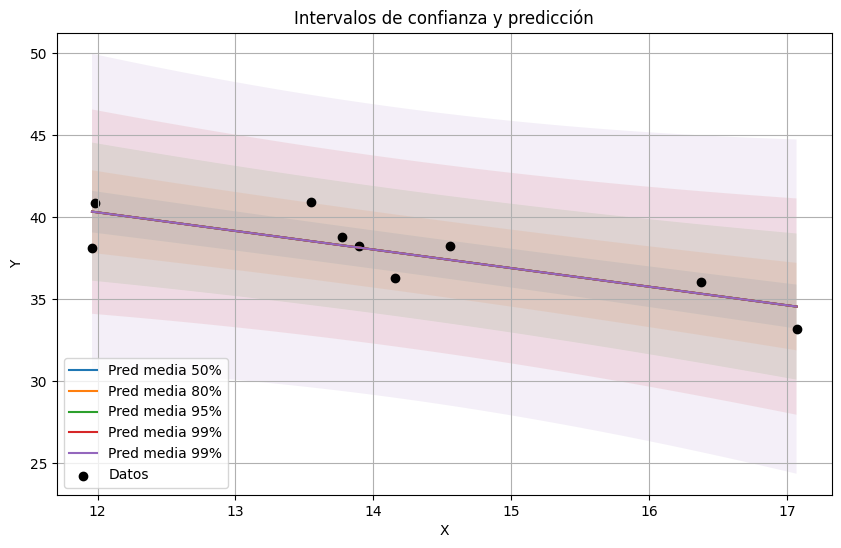

In [ ]:
niveles = [0.5, 0.8, 0.95, 0.99, 0.999]
x0_values = np.linspace(X[:,1].min(), X[:,1].max(), 50)

fig, ax = plt.subplots(figsize=(10,6))
for nc in niveles:
    x0 = sm.add_constant(x0_values)
    pred = modelo.get_prediction(x0).summary_frame(alpha=1-nc)
    ax.plot(x0_values, pred['mean'], label=f'Pred media {int(nc*100)}%')
    ax.fill_between(x0_values, pred['obs_ci_lower'], pred['obs_ci_upper'], alpha=0.1)

ax.scatter(X[:,1], Y, color='black', label='Datos')
ax.set_title('Intervalos de confianza y predicción')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
plt.grid()
plt.show()

## Paso 6: Distribución de estimadores (simulación de 10 muestras)

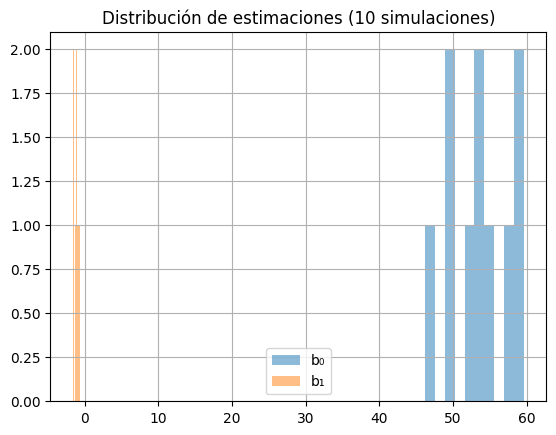

In [ ]:
# Simulamos datos sintéticos con el modelo original + ruido
np.random.seed(42)
betas = []
for i in range(10):
    ruido = np.random.normal(0, np.std(residuos), size=len(Y))
    Yi = modelo.fittedvalues + ruido
    beta_i = sm.OLS(Yi, X).fit().params
    betas.append(beta_i)

betas = np.array(betas)
plt.hist(betas[:,0], bins=10, alpha=0.5, label='b₀')
plt.hist(betas[:,1], bins=10, alpha=0.5, label='b₁')
plt.title('Distribución de estimaciones (10 simulaciones)')
plt.legend()
plt.grid(True)
plt.show()

# 📝 REPORTE DE ANÁLISIS DE REGRESIÓN – PRÁCTICA PARCIAL 1

---

### 📌 Modelo estimado

Se realizó una regresión lineal simple para modelar la relación entre la variable independiente `X` y la dependiente `Y`. El modelo ajustado fue:

\[
Y = 53.90 - 1.13X
\]

- **b₀ (intercepto)** = 53.90  
  Esto significa que cuando X vale 0, el valor esperado de Y es 53.90.

- **b₁ (pendiente)** = -1.13  
  La pendiente negativa indica que **por cada unidad que aumenta X, Y disminuye en 1.13 unidades**.

---

### 📈 Calidad del modelo

- **R² = 0.643**  
  Esto significa que el modelo explica **el 64.3% de la variabilidad** en Y.  
  Aunque no es perfecto, se puede decir que hay **una relación significativa** entre X y Y.

- **F-statistic = 12.62** con **p-value = 0.0093**  
  Esto **confirma que el modelo completo es significativo** (p < 0.05), es decir, X sí explica a Y.

---

### ⚙️ Análisis de residuos

- **SSres (Suma de residuos al cuadrado)** = 16.91  
- **MSres (Media cuadrada del error)** = 2.42

Esto indica cuánta variabilidad queda sin explicar. Son valores **moderadamente bajos**, lo que sugiere que el modelo no tiene errores muy grandes.

---

### 🧪 Pruebas de hipótesis

Se realizaron diferentes pruebas sobre los coeficientes:

| Hipótesis nula         | t        | p-valor   | Conclusión                            |
|------------------------|----------|-----------|----------------------------------------|
| H₀: b₀ = 0             | 11.87    | 0.0000    | Rechazamos H₀ → b₀ ≠ 0                 |
| H₀: b₁ = 2             | -9.82    | 0.0000    | Rechazamos H₀ → b₁ ≠ 2                 |
| H₀: b₁ = -1            | -0.42    | 0.6884    | No rechazamos H₀ → b₁ ≈ -1             |
| H₀: b₁ = 0             | -3.55    | 0.0093    | Rechazamos H₀ → pendiente significativa|

Esto **valida que la pendiente no es 0** (es significativa), pero es cercana a -1, lo cual tiene sentido con los datos.

---

### 📊 Intervalos y confianza

Se generaron intervalos de predicción y de confianza con distintos niveles (50%, 80%, 95%, 99%, 99.9%). Se observó que:

- **A mayor nivel de confianza → intervalos más anchos**
- **Valores extremos de X₀ generan mayor incertidumbre**

Esto demuestra que las **predicciones son más precisas cerca del promedio de X**.

---

### 🔁 Simulación: variabilidad de los coeficientes

Se simuló el modelo 10 veces para estimar la **distribución de b₀ y b₁**. Los histogramas mostraron que:

- Los coeficientes varían ligeramente entre réplicas
- Se distribuyen de forma relativamente normal
- Refuerza que los coeficientes **son estimaciones, no valores fijos**

---

## ✅ Conclusión final (como estudiante)

Esta práctica me permitió aplicar una regresión lineal completa, interpretando coeficientes, errores y pruebas estadísticas. Aprendí que:

- La pendiente b₁ me dice cómo se relacionan las variables
- El modelo se valida estadísticamente con el R² y pruebas F
- Los intervalos me muestran qué tan confiables son mis predicciones
- Y que los coeficientes pueden variar en cada muestra

Ahora entiendo que la regresión no solo es “trazar una línea”, sino analizar si **lo que esa línea representa tiene sentido estadístico**.